# DermaVision - Phase 4: FL (Non-IID) - MobileNetV2 (High Accuracy)

**Configuration**: Fine-Tuning with **Frozen BatchNormalization**.

---

In [14]:
# Ensure dependencies are installed via requirements.txt or pip
%pip install -q flwr[simulation] tensorflow

Note: you may need to restart the kernel to use updated packages.


In [15]:
import numpy as np
import tensorflow as tf
import os
import shutil
import glob

BACKUP_DIR = 'backup/DermaVision'

# Load Data
if os.path.exists('X_train.npy'):
    print("Loading data from local storage...")
elif os.path.exists(os.path.join(BACKUP_DIR, 'X_train.npy')):
    print(f"Loading data from backup ({BACKUP_DIR})...")
    for file in ['X_train.npy', 'y_train.npy', 'X_val.npy', 'y_val.npy', 'X_test.npy', 'y_test.npy']:
        shutil.copy(os.path.join(BACKUP_DIR, file), '.')
else:
    print("ERROR: Data not found! Please run 01_DataSetup.ipynb first.")

if os.path.exists('X_train.npy'):
    X_train = np.load('X_train.npy')
    y_train = np.load('y_train.npy')
    X_val = np.load('X_val.npy')
    y_val = np.load('y_val.npy')
    X_test = np.load('X_test.npy')
    y_test = np.load('y_test.npy')

Loading data from local storage...


In [16]:
NUM_CLIENTS = 10

def split_data_noniid(X, y, num_clients):
    y_labels = np.argmax(y, axis=1)
    class_indices = {}
    for class_idx in range(4):
        class_indices[class_idx] = np.where(y_labels == class_idx)[0]
        np.random.shuffle(class_indices[class_idx])
    
    client_data = {i: {'X': [], 'y': []} for i in range(num_clients)}
    
    for client_id in range(num_clients):
        primary_class = client_id % 4
        primary_indices = class_indices[primary_class]
        n_primary = int(len(primary_indices) * 0.7)
        
        client_data[client_id]['X'].extend(X[primary_indices[:n_primary]])
        client_data[client_id]['y'].extend(y[primary_indices[:n_primary]])
        
        for other_class in range(4):
            if other_class != primary_class:
                other_indices = class_indices[other_class]
                n_other = int(len(other_indices) * 0.15)
                client_data[client_id]['X'].extend(X[other_indices[:n_other]])
                client_data[client_id]['y'].extend(y[other_indices[:n_other]])
    
    X_clients = [np.array(client_data[i]['X']) for i in range(num_clients)]
    y_clients = [np.array(client_data[i]['y']) for i in range(num_clients)]
    return X_clients, y_clients

X_clients, y_clients = split_data_noniid(X_train, y_train, NUM_CLIENTS)

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input, Rescaling, RandomFlip, RandomRotation
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

def create_model():
    """Create MobileNetV2 with Fine-Tuning enabled but BN Frozen."""
    inputs = Input(shape=(128, 128, 3))
    
    x = RandomFlip("horizontal_and_vertical")(inputs)
    x = RandomRotation(0.2)(x)
    x = Rescaling(scale=2.0, offset=-1.0)(x)
    
    base_model = MobileNetV2(
        input_tensor=x,
        include_top=False,
        weights='imagenet'
    )
    
    # Fine-Tuning: Unfreeze weights, but FREEZE BN stats
    base_model.trainable = True
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(4, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

In [18]:
import gc

NUM_ROUNDS = 50
LOCAL_EPOCHS = 5
BATCH_SIZE = 32

print(f"Starting Non-IID FL...")

global_model = create_model()
global_model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
global_weights = global_model.get_weights()

for round_num in range(1, NUM_ROUNDS + 1):
    print(f"\nRound {round_num}/{NUM_ROUNDS}")
    client_weights = []
    client_sizes = []
    
    for i in range(NUM_CLIENTS):
        tf.keras.backend.clear_session()
        client_model = create_model()
        client_model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
        client_model.set_weights(global_weights)
        client_model.fit(X_clients[i], y_clients[i], epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
        client_weights.append(client_model.get_weights())
        client_sizes.append(len(X_clients[i]))
        del client_model
        gc.collect()
    
    total_size = sum(client_sizes)
    new_weights = []
    for layer_idx in range(len(client_weights[0])):
        layer_avg = np.zeros_like(client_weights[0][layer_idx])
        for client_idx in range(NUM_CLIENTS):
            weight = client_sizes[client_idx] / total_size
            layer_avg += weight * client_weights[client_idx][layer_idx]
        new_weights.append(layer_avg)
    
    tf.keras.backend.clear_session()
    global_model = create_model()
    global_model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
    global_weights = new_weights
    global_model.set_weights(global_weights)
    
    loss, acc = global_model.evaluate(X_val, y_val, verbose=0)
    print(f"  -> Val Acc: {acc*100:.2f}%")

loss, acc = global_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%")

Starting Non-IID FL...


C:\Users\Sev\AppData\Local\Temp\ipykernel_26780\3280983545.py:15: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(



Round 1/50
  -> Val Acc: 48.67%

Round 2/50
  -> Val Acc: 56.67%

Round 3/50
  -> Val Acc: 60.22%

Round 4/50
  -> Val Acc: 61.33%

Round 5/50
  -> Val Acc: 62.00%

Round 6/50
  -> Val Acc: 63.56%

Round 7/50
  -> Val Acc: 64.00%

Round 8/50
  -> Val Acc: 63.33%

Round 9/50
  -> Val Acc: 64.67%

Round 10/50
  -> Val Acc: 63.56%

Round 11/50
  -> Val Acc: 65.33%

Round 12/50
  -> Val Acc: 65.11%

Round 13/50
  -> Val Acc: 64.67%

Round 14/50
  -> Val Acc: 66.22%

Round 15/50
  -> Val Acc: 65.33%

Round 16/50
  -> Val Acc: 65.11%

Round 17/50
  -> Val Acc: 66.67%

Round 18/50
  -> Val Acc: 66.22%

Round 19/50
  -> Val Acc: 65.78%

Round 20/50
  -> Val Acc: 65.11%

Round 21/50
  -> Val Acc: 67.56%

Round 22/50
  -> Val Acc: 67.11%

Round 23/50
  -> Val Acc: 66.00%

Round 24/50
  -> Val Acc: 66.67%

Round 25/50
  -> Val Acc: 65.78%

Round 26/50
  -> Val Acc: 66.67%

Round 27/50
  -> Val Acc: 67.78%

Round 28/50
  -> Val Acc: 66.67%

Round 29/50
  -> Val Acc: 67.11%

Round 30/50
  -> Val A

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step


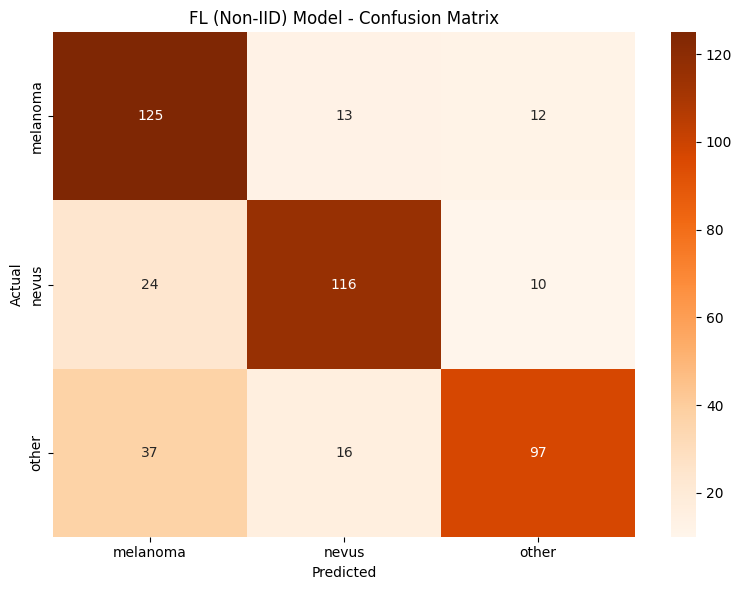

Saved fl_noniid_confusion_matrix.png


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = global_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['invalid', 'melanoma', 'nevus', 'other'], yticklabels=['invalid', 'melanoma', 'nevus', 'other'])
plt.title('FL (Non-IID) Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('fl_noniid_confusion_matrix.png', dpi=100)
plt.show()

print("Saved fl_noniid_confusion_matrix.png")

In [20]:
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=['invalid', 'melanoma', 'nevus', 'other']))


Classification Report:
              precision    recall  f1-score   support

    melanoma       0.67      0.83      0.74       150
       nevus       0.80      0.77      0.79       150
       other       0.82      0.65      0.72       150

    accuracy                           0.75       450
   macro avg       0.76      0.75      0.75       450
weighted avg       0.76      0.75      0.75       450



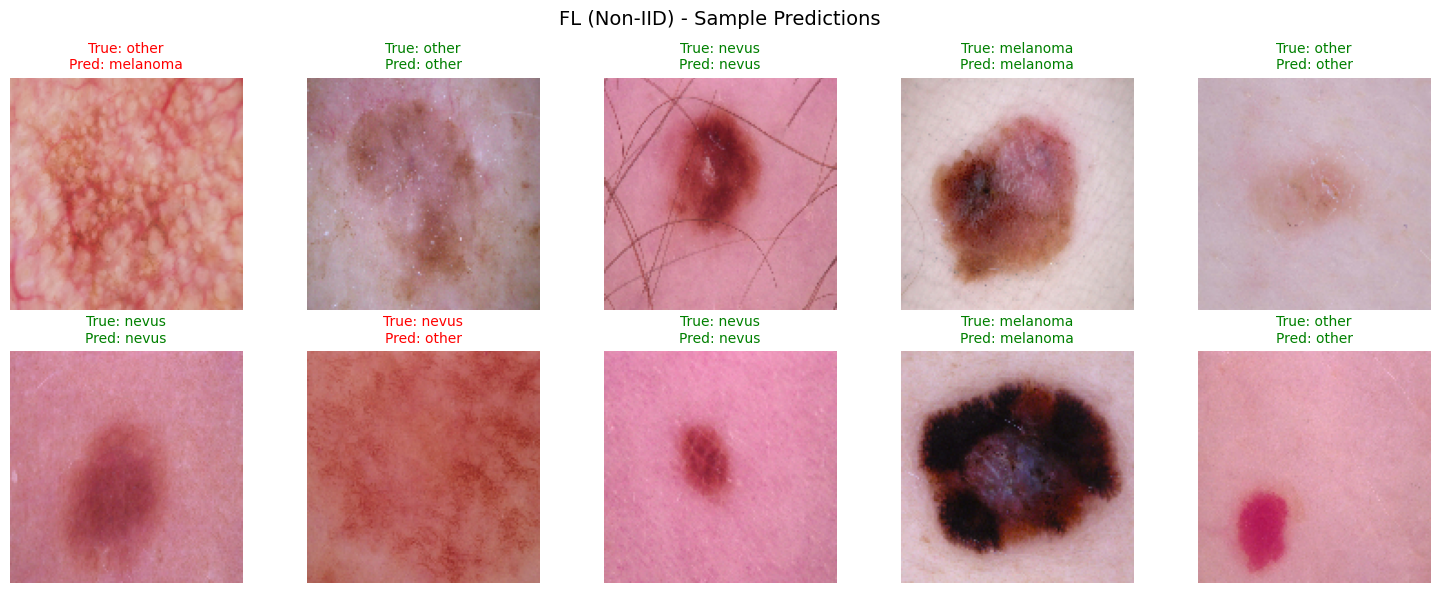

In [21]:
# Sample Predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
indices = np.random.choice(len(X_test), 10, replace=False)
label_classes = ['melanoma', 'nevus', 'other']

for i, idx in enumerate(indices):
    row = i // 5
    col = i % 5
    axes[row, col].imshow(X_test[idx])
    axes[row, col].axis('off')
    true_label = label_classes[y_true_classes[idx]]
    pred_label = label_classes[y_pred_classes[idx]]
    color = 'green' if true_label == pred_label else 'red'
    axes[row, col].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)

plt.suptitle('FL (Non-IID) - Sample Predictions', fontsize=14)
plt.tight_layout()
plt.savefig('fl_noniid_predictions.png', dpi=100)
plt.show()

In [22]:
# Save and Backup
global_model.save('fl_noniid_model.keras')
with open('fl_noniid_results.txt', 'w') as f:
    f.write(f"Test Accuracy: {acc*100:.2f}%")

import glob
os.makedirs(BACKUP_DIR, exist_ok=True)
shutil.copy('fl_noniid_model.keras', BACKUP_DIR)
for file in glob.glob('fl_noniid_*.png'):
    shutil.copy(file, BACKUP_DIR)
shutil.copy('fl_noniid_results.txt', BACKUP_DIR)

print(f"Results backed up to {BACKUP_DIR}")

Results backed up to backup/DermaVision
